In [2]:
import clusim.sim as sim
from clusim.clustering import Clustering
import numpy as np
# conda activate SPACEL
def cons_coef(adata1, adata2, cluster1, cluster2, return_all=True, alpha=.9):
    obs_names = adata1.obs_names
    c1 = Clustering(elm2clu_dict = {index: [value] for index, value in zip(obs_names, adata1.obs[cluster1])})
    
    c2 = Clustering(elm2clu_dict = {index: [value] for index, value in zip(obs_names, adata2.obs[cluster2])})
    sis, relabeled_elements = sim.element_sim_elscore(c1, c2, alpha=alpha)
    
    sis_mapped = np.zeros(len(obs_names))

    for obs_index, score_position in relabeled_elements.items():
        sis_mapped[obs_names.get_loc(obs_index)] = sis[score_position]
        
    if return_all:
        return sis_mapped, np.mean(sis_mapped)
    else:
        return sis_mapped

In [4]:
from sklearn.metrics import adjusted_rand_score
import pandas as pd 
import os.path as osp
import scanpy as sc
slice_ids = ["2", "3", "4", "5", "6", "7", "9", "11", "17", "18", "19", "23", "24", "25", "26", "28", "33", "34", "36"]
def load_HMlymphNode(root_dir = '/maiziezhou_lab/Datasets/ST_datasets/humanMetastaticLymphNode/GSE251926_metastatic_lymph_node_3d.h5ad', section_id =  "1"):
    adataT = sc.read_h5ad(root_dir)
    section_id = int(section_id)  # Convert section_id to integer
    slice1 = adataT[adataT.obs['n_section'] == section_id]
    if 'gene_ids' not in slice1.var.columns:
        slice1.var['gene_ids'] = slice1.var_names
    slice1.obs['original_clusters'] = slice1.obs['annotation']
    slice1.obs['batch'] = section_id
    return slice1
section_ids = [4, 10]
 #----------------
reference_data = load_HMlymphNode(section_id= slice_ids[4])
puck = load_HMlymphNode(section_id= slice_ids[10])

/tmp/ipykernel_418808/1352212737.py:13: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  slice1.var['gene_ids'] = slice1.var_names
/tmp/ipykernel_418808/1352212737.py:13: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  slice1.var['gene_ids'] = slice1.var_names


In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import confusion_matrix
from scipy.spatial.distance import *
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import scanpy as sc
import os, os.path as osp
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn import metrics
methods = ['Seurat', 'CARD', 'cell2location', 'GraphST', 'DestVI','RCTD', 'scVI', 'SingleR', 'spatialDWLS', 'spatialID','spotlight','tacco','Tangram']
from sklearn.metrics import adjusted_rand_score
def ASW_score(X, pred_labels):
    d = squareform(pdist(X))
    return silhouette_score(X=d,labels=pred_labels,metric='precomputed')
total = []
#ad_train = sc.read_h5ad('/maiziezhou_lab2/yuling/MERFISH_spinal_cord_resolved_0718.h5ad')
st_data = puck
for m in methods:
    out_rows = []  
    
    pred_label = pd.read_csv(f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/{m}/HumanLymph_output/merged_pred.csv', index_col=0)
    
    X = st_data.obsm['spatial']
    y_true = pred_label['original_clusters'].astype(str).to_numpy()
    y_pred = pred_label['pred'].astype(str).to_numpy()
    st_data.obs['pred'] = y_pred
    #y_true = np.char.replace(y_true, '_', '/')
    #y_pred = np.char.replace(y_pred, '_', '/')
    labels = np.unique(y_true)  # ensure we average over true classes
    precision_macro = precision_score(
        y_true, y_pred, labels=labels, average="macro", zero_division=0
    )

    labels = np.unique(np.concatenate([y_true, y_pred]))
    le = LabelEncoder().fit(labels)
    yt = le.transform(y_true)
    yp = le.transform(y_pred)
    mask = (yt == yp)
    n_correct = np.count_nonzero(mask)   
    n_total = mask.size
    acc = n_correct / n_total
    X = st_data.obsm['spatial']
    asw = ASW_score(X=X, pred_labels= y_pred)
    print(f"correct: {n_correct}/{n_total} ({acc:.2%})")
    asw = (asw + 1.0) / 2.0
    asw = max(0.0, min(1.0, float(asw)))
    f1_macro    = f1_score(yt, yp, average='macro')
    f1_weighted = f1_score(yt, yp, average='weighted')
    f1_micro    = f1_score(yt, yp, average='micro')  
    sis_map, mean_val = cons_coef(st_data, st_data, 'original_clusters', 'pred', return_all=True, alpha=.9)
    ari = adjusted_rand_score(yp, yt)
    recall_macro = recall_score(y_true, y_pred, average="macro") 
    ami = metrics.adjusted_mutual_info_score(y_true, y_pred)
    nmi = metrics.normalized_mutual_info_score(y_true, y_pred)
    avgbio = (nmi + ari + asw) / 3.0 if np.isfinite(asw) else np.nan
    
    out_rows.append({
        'Method': m, 
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_micro': f1_micro,
        'precision': precision_macro,
        'recall': recall_macro,
        'ARI': ari,
        'AMI': ami,
        'NMI': nmi,
        'ASW': asw,
        'AvgBIO': avgbio,
        'ECS': mean_val
    })
    total.append({
        'Method': m, 
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_micro': f1_micro,
        'precision': precision_macro,
        'recall': recall_macro,
        'ARI': ari,
        'AMI': ami,
        'NMI': nmi,
        'ASW': asw,
        'AvgBIO': avgbio,
        'ECS': mean_val
    })
    results_df = pd.DataFrame(out_rows)
    output_path = f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/{m}/HumanLymph_output/metrics_results.csv'
    results_df.to_csv(output_path, index=False)
    print(f"\nResults saved to: {output_path}")

# Display the results nicely
print("\nMetrics Summary:")
print(pd.DataFrame(total))

correct: 22154/39167 (56.56%)

Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Seurat/HumanLymph_output/metrics_results.csv
correct: 21162/39167 (54.03%)

Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/CARD/HumanLymph_output/metrics_results.csv
correct: 20940/39167 (53.46%)

Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/cell2location/HumanLymph_output/metrics_results.csv
correct: 9905/39167 (25.29%)

Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/GraphST/HumanLymph_output/metrics_results.csv
correct: 22454/39167 (57.33%)

Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/DestVI/HumanLymph_output/metrics_results.csv
correct: 18633/39167 (47.57%)


/home/zhuy45/miniconda3/envs/SPACEL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/RCTD/HumanLymph_output/metrics_results.csv
correct: 25647/39167 (65.48%)

Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scVI/HumanLymph_output/metrics_results.csv
correct: 21027/39167 (53.69%)

Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SingleR/HumanLymph_output/metrics_results.csv
correct: 19300/39167 (49.28%)

Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialDWLS/HumanLymph_output/metrics_results.csv
correct: 25208/39167 (64.36%)

Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialID/HumanLymph_output/metrics_results.csv
correct: 19240/39167 (49.12%)

Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spotlight/HumanLymph_output/metrics_results.csv
correct: 24465/39167 (62.46%)

Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/tacco/HumanLymph_output/metrics_results.csv
correct:

# visualize bar plot 

In [8]:
def plot_metrics_seaborn(folder_paths, output_filename='metrics_comparison_seaborn_h.png',
                         method_colors=None):
    if isinstance(folder_paths, list):
        folder_dict = {os.path.basename(path): path for path in folder_paths}
    else:
        folder_dict = folder_paths

    metrics_list = ['accuracy', 'f1_macro', 'f1_weighted', 'precision', 'recall', 'ECS', 'ARI', 'AMI', 'AvgBIO']
    long_rows, acc_map = [], {}
    for method, folder_path in folder_dict.items():
        csv_path = os.path.join(folder_path, 'metrics_results.csv')
        if not os.path.exists(csv_path):
            print(f"[MISS] {method}: {csv_path} not exist")
            continue
        try:
            df = pd.read_csv(csv_path)
            if len(df) == 0:
                print(f"[EMPTY] {method}: {csv_path} without data")
                continue
            row = df.iloc[0].to_dict()
            acc_map[method] = float(row.get('accuracy', float('-inf')))
            for m in metrics_list:
                if m in row and pd.notna(row[m]):
                    long_rows.append({'Method': method, 'Metric': m, 'Value': float(row[m])})
        except Exception as e:
            print(f"[READ ERR] {method}: {e}")

    plot_df = pd.DataFrame(long_rows)
    if plot_df.empty:
        return plot_df
    methods_in_data = plot_df['Method'].unique().tolist()
    method_order = sorted(methods_in_data, key=lambda m: acc_map.get(m, float('-inf')), reverse=True)
    plot_df['Metric'] = pd.Categorical(plot_df['Metric'], categories=metrics_list, ordered=True)
    default_colors = [
        '#1f77b4', '#ff7f0e', '#1b9e77', '#d62728', '#9467bd', "#9edae5", "#c49c94","#A6D854",
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#393b79', '#000000', '#ad494a'
    ]
    method_colors = method_colors or {}
    palette = {}
    used = set()
    for m, c in method_colors.items():
        if m in methods_in_data and isinstance(c, str):
            palette[m] = c
            used.add(c.lower())

    missing = [m for m in method_order if m not in method_colors]
    print("Missing colors for methods:", missing)
    print("Provided colors:", len(method_colors))

    available = [c for c in default_colors if c.lower() not in used]
    ai = 0
    for m in method_order:
        if m not in palette:
            palette[m] = available[ai % len(available)]
            ai += 1
    # ============================================================
    plt.figure(figsize=(16, 22))
    ax = sns.barplot(
        data=plot_df,
        x='Value', y='Metric',
        hue='Method',
        hue_order=method_order,  
        palette=palette,
        orient='h',
        width=0.9
    )
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
    title_fs, axis_label_fs, tick_fs = 18, 14, 14
    plt.title('Metrics Comparison Across Different Methods (Human Lymph Node)',
              fontsize=title_fs, fontweight='bold')
    plt.xlabel('Values', fontsize=axis_label_fs)
    plt.ylabel('Metrics', fontsize=axis_label_fs)
    ax.tick_params(axis='both', labelsize=tick_fs)
    plt.grid(True, alpha=0.3, axis='x')
    plt.legend(title='Methods', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    #plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.savefig('/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/HumanLymph/metrics_comparison.pdf',
            bbox_inches='tight')

    plt.show()
    rank_df = (pd.Series(acc_map, name='accuracy')
               .loc[method_order]
               .reset_index().rename(columns={'index': 'Method'}))
    print("\n[Method order by accuracy (desc)]")
    print(rank_df.to_string(index=False, float_format='%.4f'))

    return plot_df


Missing colors for methods: []
Provided colors: 21


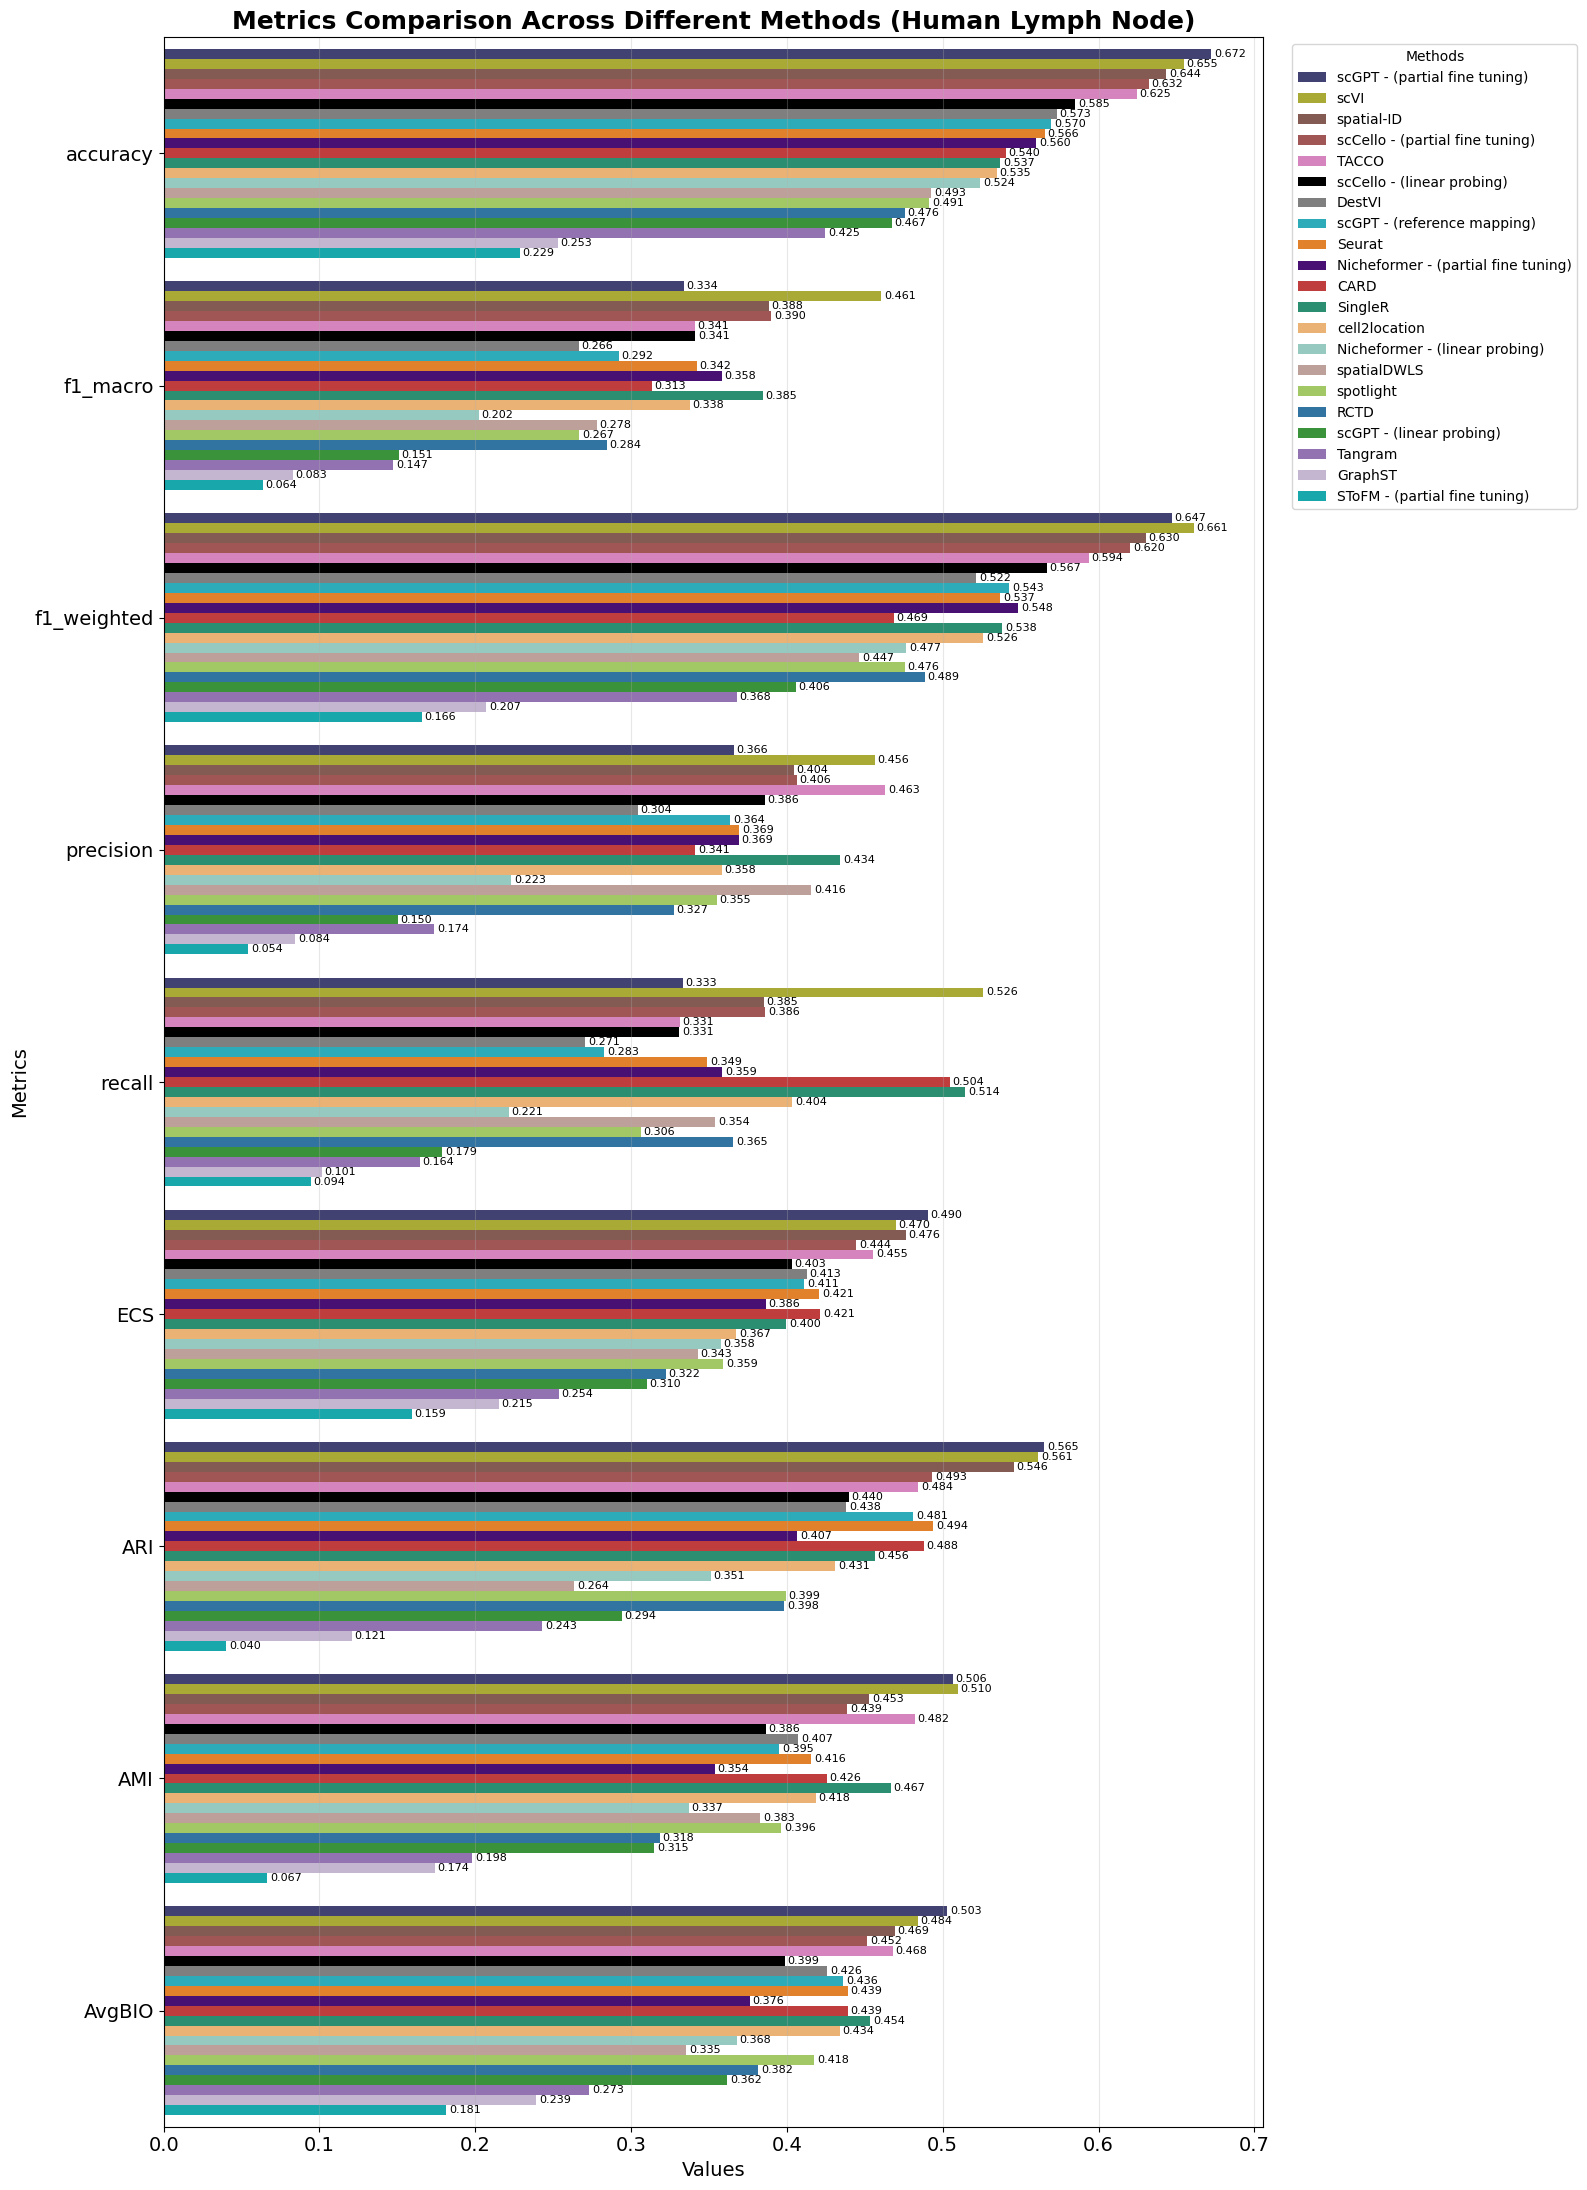


[Method order by accuracy (desc)]
                             Method  accuracy
      scGPT - (partial fine tuning)    0.6722
                               scVI    0.6548
                         spatial-ID    0.6436
    scCello - (partial fine tuning)    0.6322
                              TACCO    0.6246
         scCello - (linear probing)    0.5849
                             DestVI    0.5733
        scGPT - (reference mapping)    0.5698
                             Seurat    0.5656
Nicheformer - (partial fine tuning)    0.5601
                               CARD    0.5403
                            SingleR    0.5369
                      cell2location    0.5346
     Nicheformer - (linear probing)    0.5241
                        spatialDWLS    0.4928
                          spotlight    0.4912
                               RCTD    0.4757
           scGPT - (linear probing)    0.4674
                            Tangram    0.4245
                            GraphST    0.2529

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import numpy as np
if __name__ == "__main__":
    #
    folders = [
        '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/CARD/HumanLymph_output',
        '/path/to/TACCO/HumanLymph_output',
        '/path/to/Method3/HumanLymph_output'
    ]
    folders_dict = {
        'RCTD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/RCTD/HumanLymph_output',
        'Seurat': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Seurat/HumanLymph_output',
        'SingleR': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SingleR/HumanLymph_output',
        'CARD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/CARD/HumanLymph_output',
        'Tangram': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Tangram/HumanLymph_output',
        'cell2location': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/cell2location/HumanLymph_output',
        'spatialDWLS': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialDWLS/HumanLymph_output',
        'spotlight': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spotlight/HumanLymph_output',
        'spatial-ID': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialID/HumanLymph_output',
        'TACCO': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/tacco/HumanLymph_output',
        'DestVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/DestVI/HumanLymph_output',
        'scVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scVI/HumanLymph_output',
        'scGPT - (reference mapping)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph_reference_mapping',
        'scGPT - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph',
        'scGPT - (linear probing)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scGPT/HumanLymph_linear_probing',
        'scCello - (linear probing)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scCello/linear_probing',
        'scCello - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scCello/partial_fine_tune',
        'GraphST' : '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/GraphST/HumanLymph_output',
        'Nicheformer - (linear probing)' : '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Nicheformer/linearProbing',
        'Nicheformer - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Nicheformer/partialFineTune',
        'SToFM - (partial fine tuning)': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SToFM/linearProbing'
    }
    # results = plot_metrics_from_folders(folders_dict)
    my_colors = {
        "CARD": "#d62728",
        "cell2location": "#fdb462",   # ColorBrewer Pastel
        "DestVI": "#7f7f7f",
        "GraphST": "#c5b0d5",
        "RCTD": "#1f77b4",
        "scVI": "#bcbd22",
        "Seurat": "#ff7f0e",
        "SingleR": "#1b9e77",
        "spatialDWLS": "#c49c94",
        "spatial-ID": "#8c564b",
        "spotlight": "#A6D854",
        "TACCO": "#e377c2",
        "Tangram": "#9467bd",
        'scGPT - (reference mapping)': '#17becf',
        'scGPT - (partial fine tuning)': '#393b79',
        'scCello - (linear probing)' : '#000000',
        'scCello - (partial fine tuning)': '#ad494a',
        "scGPT - (linear probing)": "#2ca02c",        # muted green
        "Nicheformer - (linear probing)": "#8dd3c7",
        "Nicheformer - (partial fine tuning)": "#4b0082",
        "SToFM - (partial fine tuning)":"#00BFC4"
    }

    results = plot_metrics_seaborn(folders_dict, method_colors=my_colors)